In [10]:
# Core data handling
import numpy as np
import pandas as pd
# Visualization
import seaborn as sns
import matplotlib.pyplot as plt
# Modeling
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [11]:
df = pd.read_csv("divorce.csv", sep=";")
df.head()

,Atr1,Atr2,Atr3,Atr4,Atr5,Atr6,Atr7,Atr8,Atr9,Atr10,...,Atr46,Atr47,Atr48,Atr49,Atr50,Atr51,Atr52,Atr53,Atr54,Class
0,2,2,4,1,0,0,0,0,0,0,...,2,1,3,3,3,2,3,2,1,1
1,4,4,4,4,4,0,0,4,4,4,...,2,2,3,4,4,4,4,2,2,1
2,2,2,2,2,1,3,2,1,1,2,...,3,2,3,1,1,1,2,2,2,1
3,3,2,3,2,3,3,3,3,3,3,...,2,2,3,3,3,3,2,2,2,1
4,2,2,1,1,1,1,0,0,0,0,...,2,1,2,3,2,2,2,1,0,1


In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Atr1,170.0,1.776471,1.627257,0.0,0.0,2.0,3.0,4.0
Atr2,170.0,1.652941,1.468654,0.0,0.0,2.0,3.0,4.0
Atr3,170.0,1.764706,1.415444,0.0,0.0,2.0,3.0,4.0
Atr4,170.0,1.482353,1.504327,0.0,0.0,1.0,3.0,4.0
Atr5,170.0,1.541176,1.632169,0.0,0.0,1.0,3.0,4.0
Atr6,170.0,0.747059,0.904046,0.0,0.0,0.0,1.0,4.0
Atr7,170.0,0.494118,0.898698,0.0,0.0,0.0,1.0,4.0
Atr8,170.0,1.452941,1.546371,0.0,0.0,1.0,3.0,4.0
Atr9,170.0,1.458824,1.557976,0.0,0.0,1.0,3.0,4.0
Atr10,170.0,1.576471,1.421529,0.0,0.0,2.0,3.0,4.0


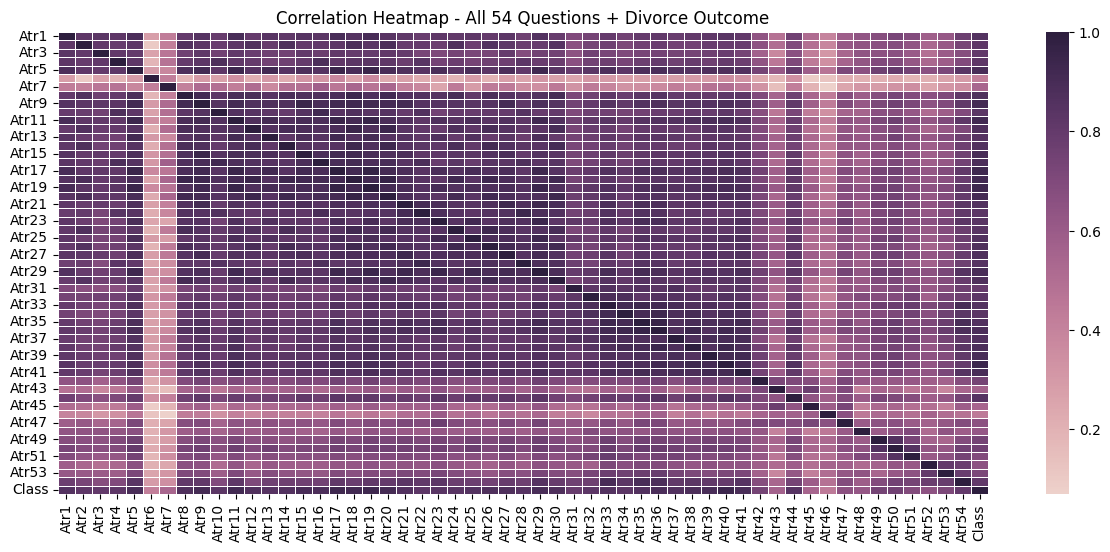

In [13]:
plt.figure(figsize=(15, 6))

sns.heatmap(
    df.corr(),
    linewidth=0.5,
    cmap=sns.cubehelix_palette(as_cmap=True)
)
plt.title("Correlation Heatmap - All 54 Questions + Divorce Outcome")
plt.show()



**What the graph shows:** Almost all 54 questions are *strongly positively correlated* with one
another (the map is dominated by one warm color block). This means couples who struggle with one
aspect of communication (e.g., "we're good at compromising") tend to also struggle with related
aspects (e.g., "we value our common goals").

**Business interpretation:** The questionnaire isn't measuring 54 independent things — it's mostly
capturing **one underlying construct**: overall relationship health/communication quality. This is
a classic sign that a smaller subset of questions could do almost all the predictive work.

**Why it matters:** For a real product (e.g., a relationship-health app), this means we could
shorten the survey from 54 questions to a handful without losing much predictive power — directly
improving user experience and completion rates.

**Possible action a company could take:** A relationship-app company could A/B test a "quick
screening" version of the survey using only the top 8-10 most correlated questions, reducing
user drop-off while keeping prediction quality high.

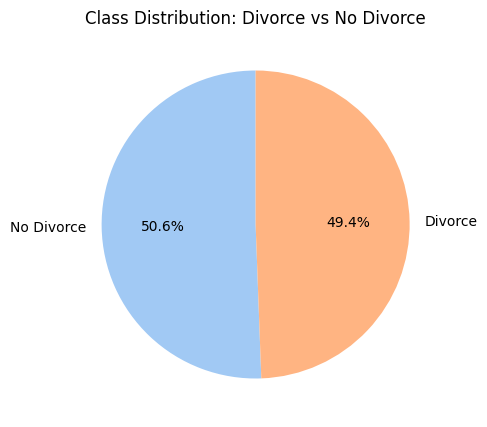

In [14]:
class_counts = df['Class'].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(
    class_counts,
    labels=['No Divorce', 'Divorce'],
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette("pastel")
)
plt.title("Class Distribution: Divorce vs No Divorce")
plt.show()


In [15]:
df.corr()['Class'].sort_values(ascending=False).head(10)

Class    1.000000
Atr40    0.938684
Atr17    0.929346
Atr19    0.928627
Atr18    0.923208
Atr11    0.918386
Atr9     0.912368
Atr20    0.907008
Atr15    0.901220
Atr39    0.896180
Name: Class, dtype: float64

### Insights: Top Correlated Questions

- **What the graph/table shows:** Questions like `Atr40`, `Atr17`, `Atr19`, and `Atr18` correlate
  extremely strongly (>0.90) with divorce outcome. Based on the Gottman-method question bank, these
  tend to map to themes like shared goals, mutual respect, and conflict-resolution style.
- **Business interpretation:** A handful of communication-related questions carry almost all of the
  predictive signal in this dataset — supporting the idea that relationship breakdown is driven by a
  **small number of core behaviours**, not by dozens of independent factors.
- **Why it matters:** This is valuable for therapists too — it suggests where to focus counseling
  effort for the highest impact (e.g., improving shared-goal alignment rather than more minor habits).
- **Possible action a company could take:** A therapy platform could build a **triage questionnaire**
  using just these top questions to flag high-risk couples early, then use the full 54-question survey
  only for those flagged cases.


In [16]:
X = df.drop(columns=['Class'])  # Features: all 54 questions
y = df['Class']                  # Target: divorce outcome (1 = divorced, 0 = married)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,   # Fixes the random split so results are reproducible
    stratify=y
)


In [17]:
# Rebuild a training-only DataFrame (features + target) so we can compute correlation safely
train_data = X_train.copy()
train_data['Class'] = y_train

# Correlation of every feature with the target, computed on TRAINING DATA ONLY
train_corr = train_data.corr()['Class']

# Keep only features with correlation >= 0.90 with the target
# (equivalently: drop everything below that threshold)
columns_to_drop = train_corr[train_corr < 0.90].index
columns_to_drop = columns_to_drop.drop('Class', errors='ignore')

print(f"Dropping {len(columns_to_drop)} weakly-correlated columns, keeping {54 - len(columns_to_drop)} strong predictors.")
print(list(columns_to_drop))


Dropping 43 weakly-correlated columns, keeping 11 strong predictors.
['Atr1', 'Atr2', 'Atr3', 'Atr4', 'Atr6', 'Atr7', 'Atr8', 'Atr10', 'Atr12', 'Atr13', 'Atr14', 'Atr16', 'Atr21', 'Atr22', 'Atr23', 'Atr24', 'Atr25', 'Atr26', 'Atr27', 'Atr28', 'Atr30', 'Atr31', 'Atr32', 'Atr33', 'Atr34', 'Atr35', 'Atr36', 'Atr37', 'Atr38', 'Atr39', 'Atr42', 'Atr43', 'Atr44', 'Atr45', 'Atr46', 'Atr47', 'Atr48', 'Atr49', 'Atr50', 'Atr51', 'Atr52', 'Atr53', 'Atr54']


In [18]:
# Apply the SAME column selection to both train and test sets
X_train = X_train.drop(columns=columns_to_drop)
X_test = X_test.drop(columns=columns_to_drop)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)


Training shape: (136, 11)
Testing shape: (34, 11)



### Why AdaBoost?
AdaBoost builds a strong model by combining many *weak* decision trees (called "stumps") in sequence.
Each new tree focuses extra attention on the examples the previous trees got wrong. This makes it
well-suited to a small, clean, tabular dataset like this one, where boosting can extract strong signal
without needing huge amounts of data.

In [19]:
# Create the AdaBoost classifier
# n_estimators=100 -> combine 100 weak decision "stump" trees sequentially
adaboost = AdaBoostClassifier(n_estimators=100, random_state=42)

# Train the model on the leakage-safe training set
adaboost.fit(X_train, y_train)

# Generate predictions on the untouched test set
y_pred = adaboost.predict(X_test)

# Evaluate using accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.2%}")


Test Accuracy: 94.12%


In [20]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['No Divorce', 'Divorce']))


Classification Report:

              precision    recall  f1-score   support

  No Divorce       0.89      1.00      0.94        17
     Divorce       1.00      0.88      0.94        17

    accuracy                           0.94        34
   macro avg       0.95      0.94      0.94        34
weighted avg       0.95      0.94      0.94        34



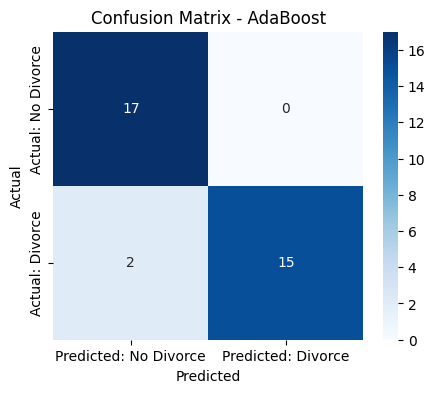

In [21]:
# Visualize the confusion matrix as a heatmap for easy interpretation
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted: No Divorce', 'Predicted: Divorce'],
    yticklabels=['Actual: No Divorce', 'Actual: Divorce']
)
plt.title("Confusion Matrix - AdaBoost")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()


In [22]:
# StratifiedKFold keeps the ~50/50 class balance consistent across every fold
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_scores = cross_val_score(adaboost, X_train, y_train, cv=cv_strategy)

print("Cross-validation scores:", np.round(cv_scores, 3))
print(f"Mean Accuracy: {cv_scores.mean():.2%}")
print(f"Standard Deviation: {cv_scores.std():.3f}")


Cross-validation scores: [1.    1.    1.    1.    1.    1.    0.923 1.    1.    0.846]
Mean Accuracy: 97.69%
Standard Deviation: 0.049


C:\Users\naren\AppData\Local\Temp\ipykernel_5024\1509475526.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="viridis")


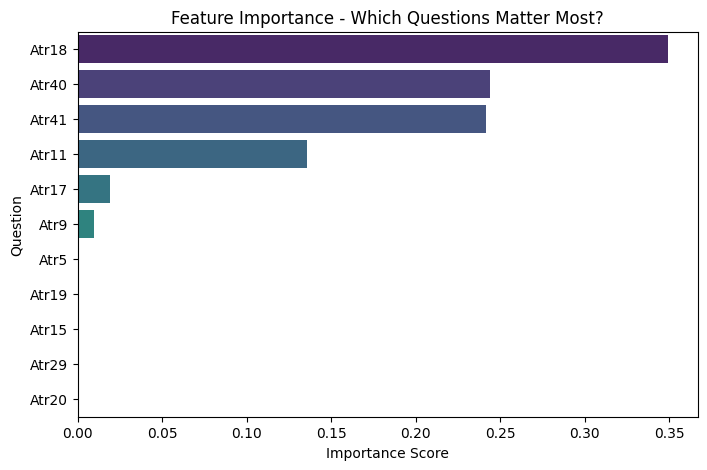

In [23]:
# Extract feature importances from the trained model
importances = pd.Series(adaboost.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Feature Importance - Which Questions Matter Most?")
plt.xlabel("Importance Score")
plt.ylabel("Question")
plt.show()


## Key Learnings

- **Leakage-safe feature selection matters:** Splitting the data *before* selecting features (rather
  than after) is a small code-ordering choice with a big impact on whether your reported accuracy can
  be trusted.
- **A handful of features can carry most of the signal:** Out of 54 survey questions, ~11 captured
  almost all the predictive power — a reminder that more features ≠ more insight.
- **Cross-validation fold count should match your sample size:** With small datasets, too many folds
  (e.g., 20 folds on 136 rows) produces noisy, unstable estimates — fold count should scale with
  available data.
- **Accuracy isn't the whole story:** Precision, recall, and the confusion matrix reveal which *type*
  of mistake the model makes — critical when false negatives and false positives have very different
  real-world costs.
